In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim

```EDA``` - изучение и предобработка данных перед обучением модели

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")                                                                                                                                                                                                                                                                                 

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

В колонке Age заметно явное отсутствие большого количества значений, можно заполнить их медианным значением, сгруппированным по колонкам Sex и Pclass(более предпочтительный вариант), можно и просто заполнить пропуски медианой

In [8]:
train["Age"] = train.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))
test["Age"] = test.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))

In [9]:
test["Fare"] = test["Fare"].fillna(test["Fare"].median())
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


колонка cabin имеет слишком много пропусков и врядли несет большую смысловую нагрузку, поэтому даже если пробовать заполнять пропущенные значения средними или медианными значениями, вряд ли из этого получится что-то дающее положительное влияние на модель, поэтому этот признак можно опустить 

In [10]:
drop_cols = ['Name', 'Ticket', 'Cabin']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

в столбец Embarked можно просто записать два значения взяв моду и это почти никак не повлияет на модель, можно и просто удалить две строки, от этого тоже не должно случиться ничего страшного и странного(я заполню пропуски модой)

In [11]:
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB


In [12]:
train.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
5,6,0,3,male,25.0,0,0,8.4583,Q
6,7,0,1,male,54.0,0,0,51.8625,S
7,8,0,3,male,2.0,3,1,21.0750,S
8,9,1,3,female,27.0,0,2,11.1333,S
9,10,1,2,female,14.0,1,0,30.0708,C


Далее я хочу провести одномерный анализ данных, то есть изучить каждый признак отдельно: увидеть распределения, есть ли выбросы, для этого поделил данные на категориальные и численные, чтобы для каждой группы строить разные графики

In [13]:
num_cols = ["Age", "Fare"]
cat_cols = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]

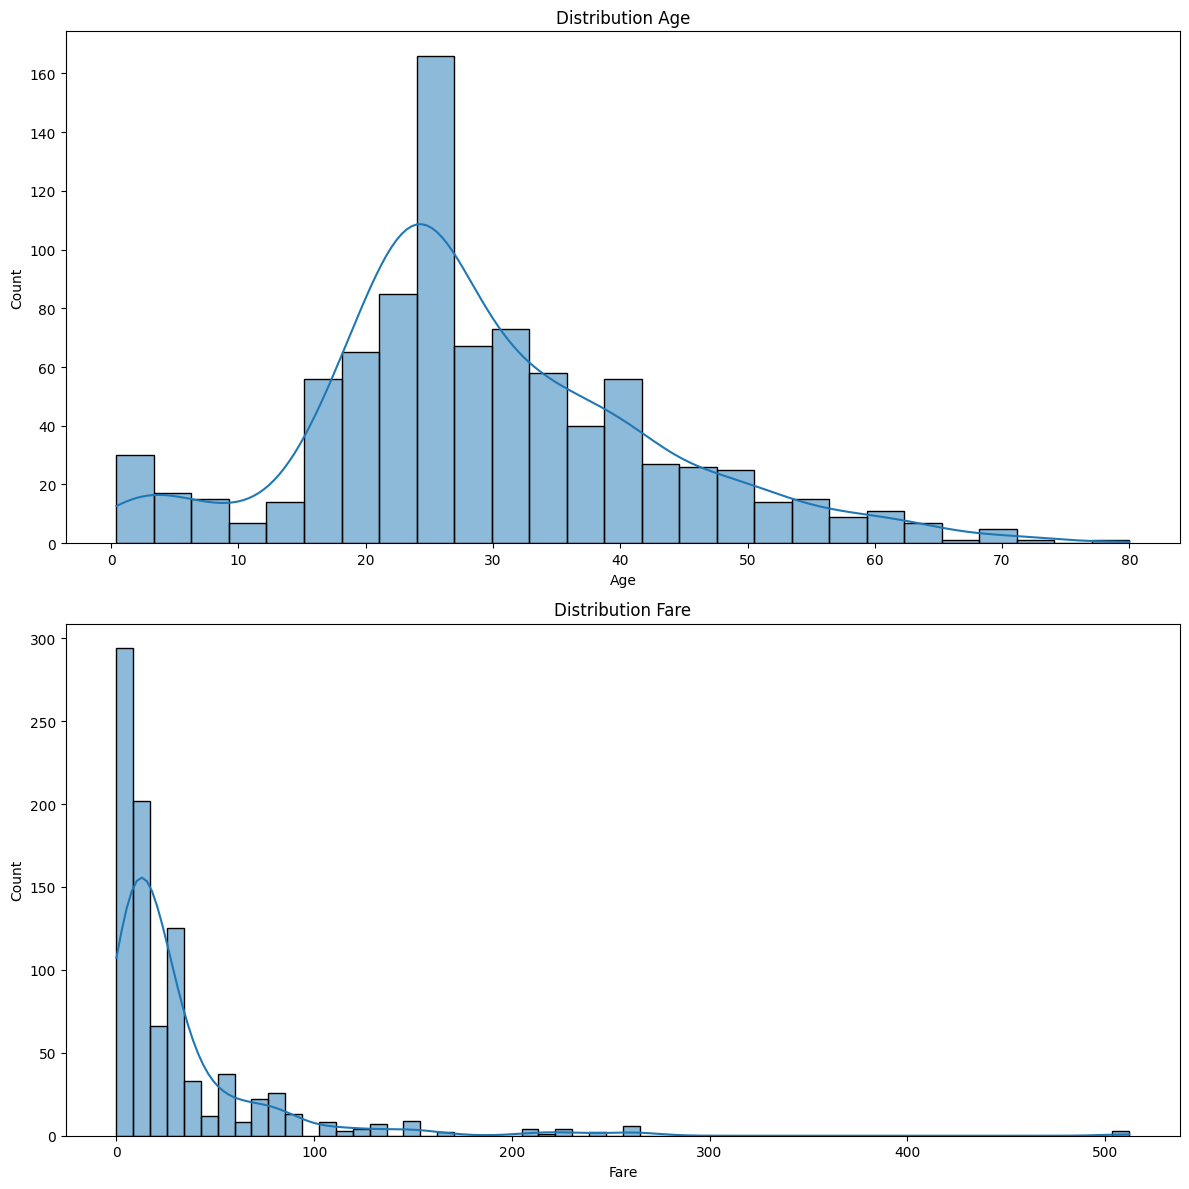

In [14]:
fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 6 * len(num_cols)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution {col}")
plt.tight_layout()
plt.show()

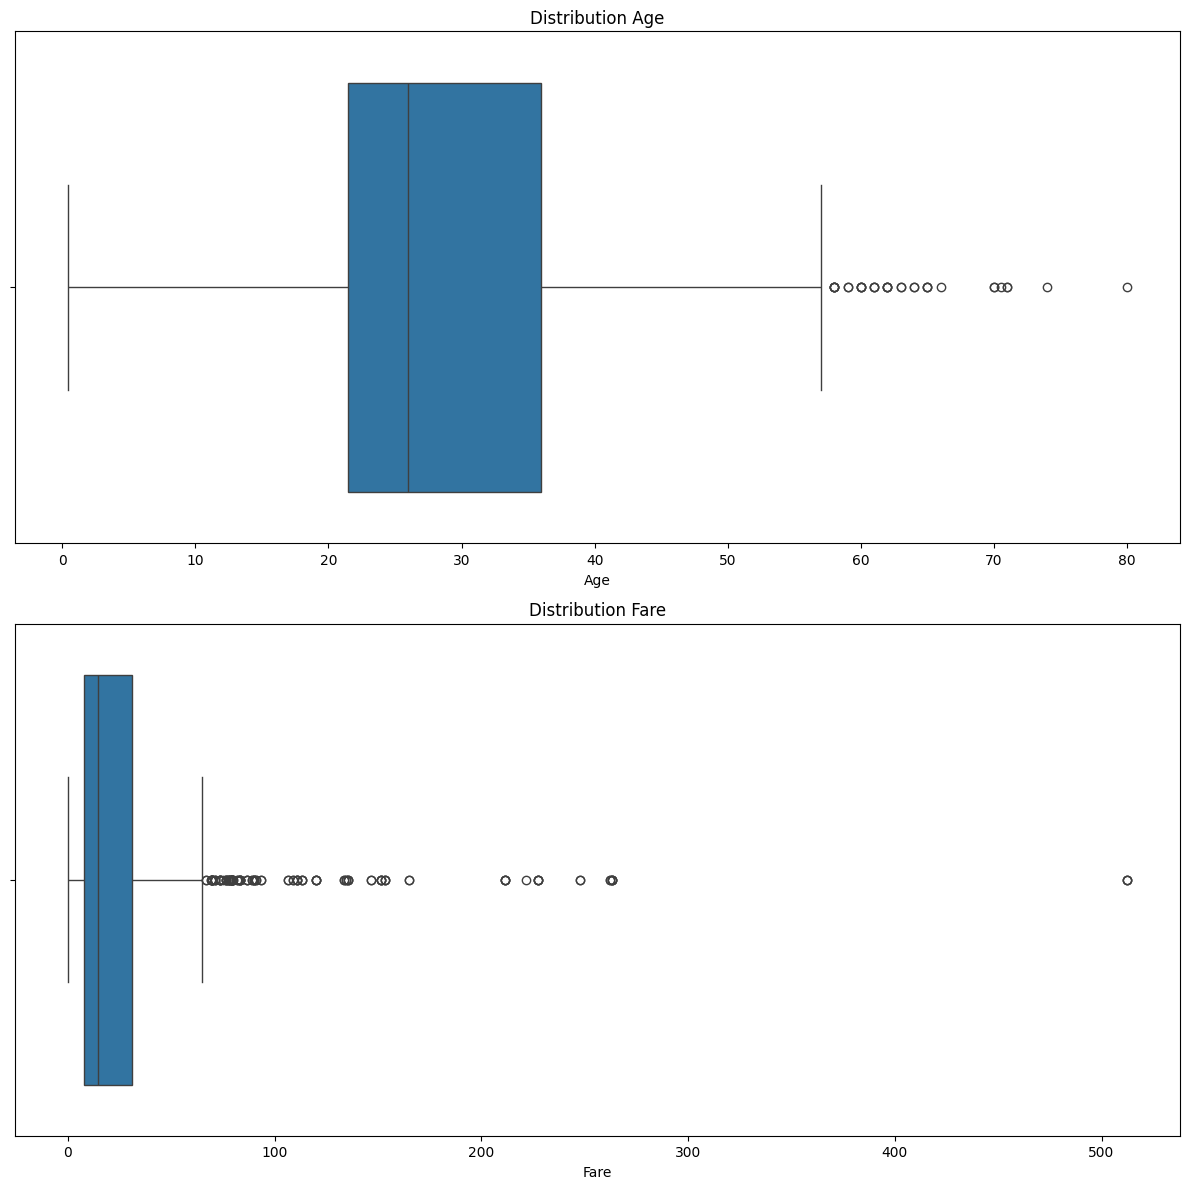

In [15]:
fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 6 * len(num_cols)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution {col}")
plt.tight_layout()
plt.show()

<Axes: xlabel='Pclass', ylabel='Fare'>

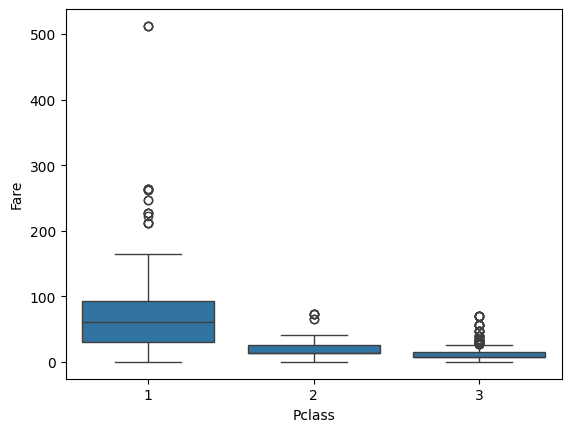

In [16]:
sns.boxplot(x='Pclass', y='Fare', data=train)

В столбце Fare имеются выбросы, которые являются естественными выбросами, поэтому их не обязательно удалять, а просто приенить к ним StandartScaler для приведения к единому диапазону

Теперь построю графики для категориальных признаков

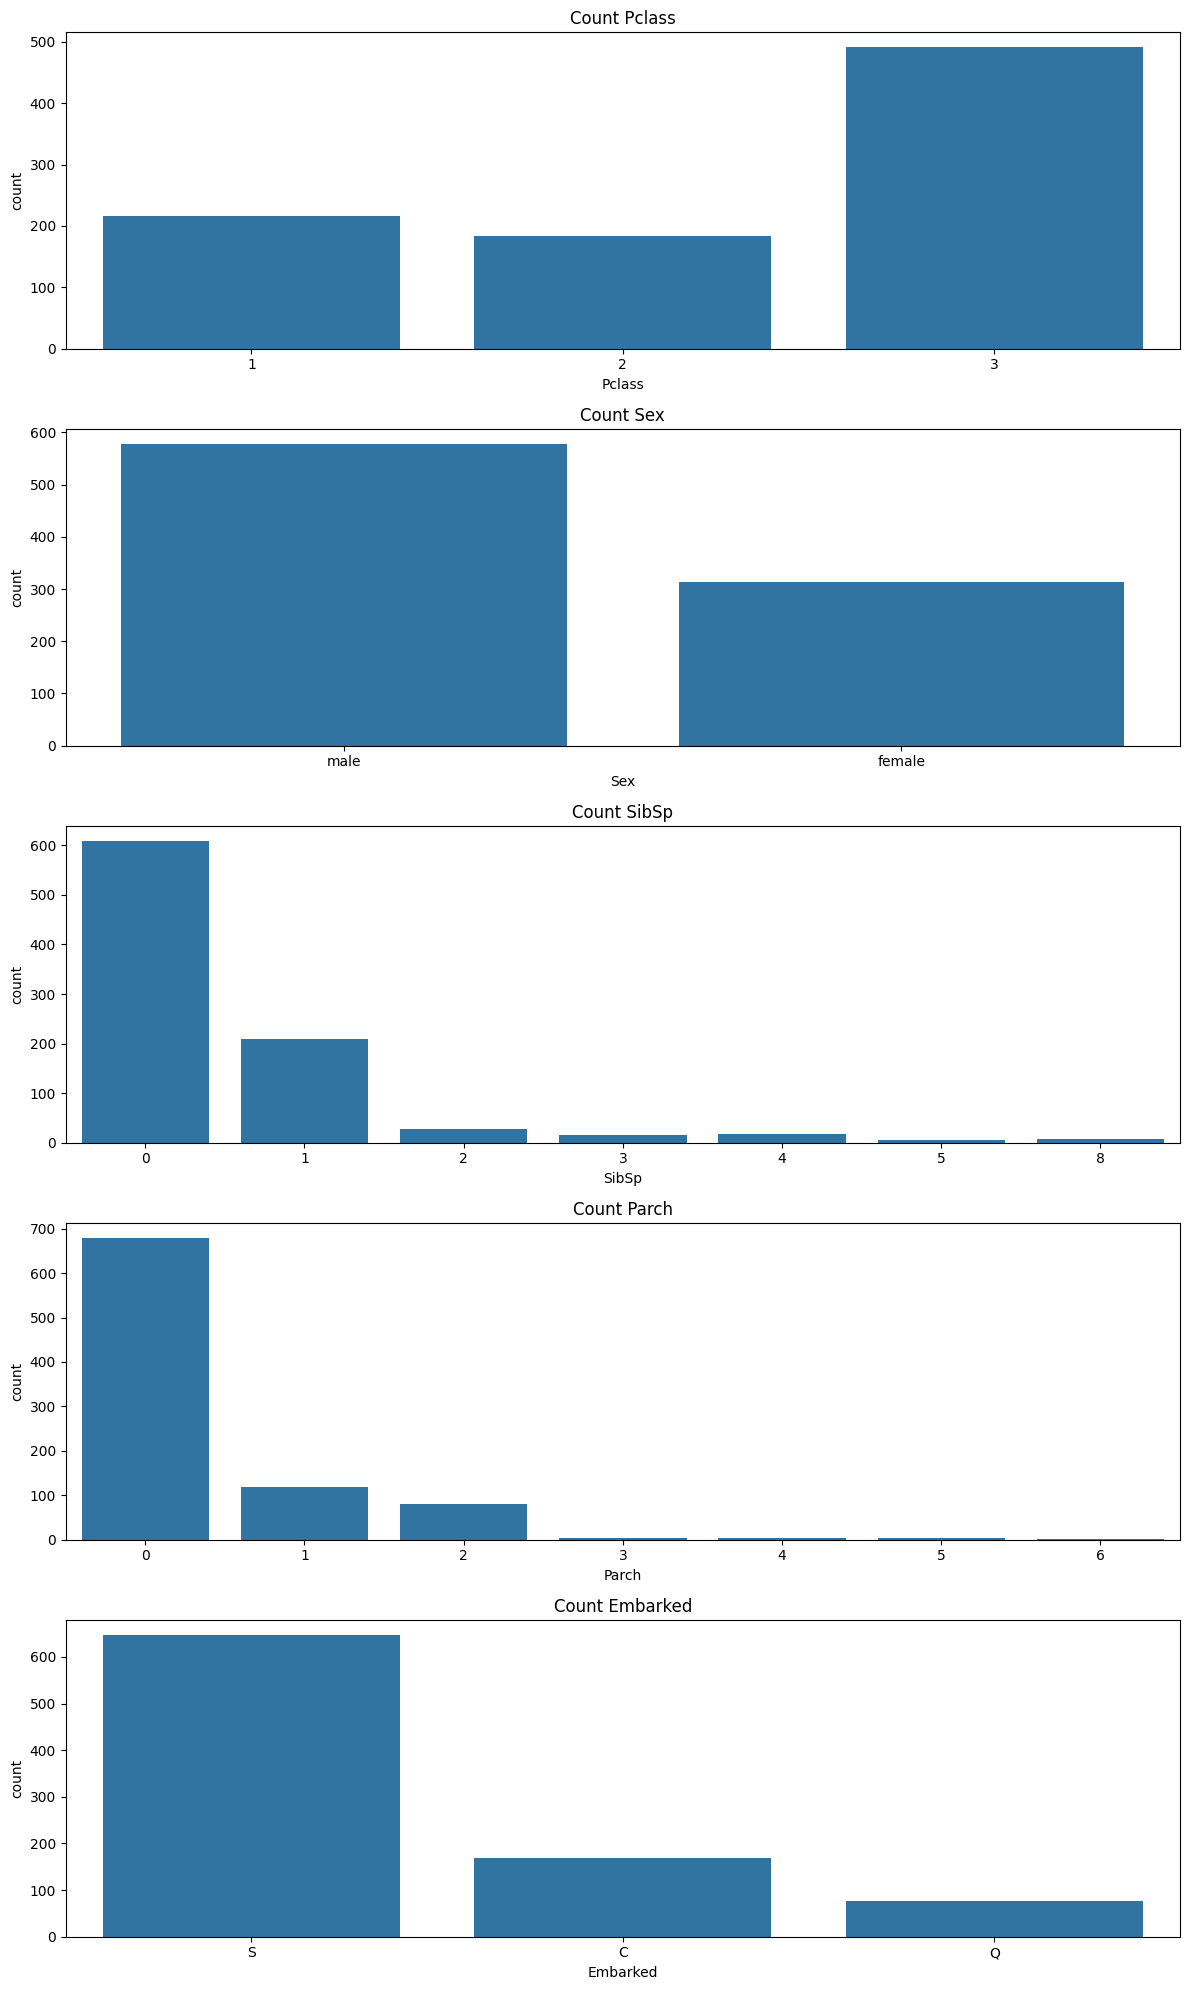

In [17]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 10 * len(num_cols)))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=train,   x=col, ax=axes[i])
    axes[i].set_title(f"Count {col}")
plt.tight_layout()
plt.show()

теперь можно перейти к просмотру зависимостей между признаком и таргетом для определения того, какой признак может оказывать наибольшее влияние на выживание и от этого можно предположить, какие признаки можно еще создать для повышения качества модели

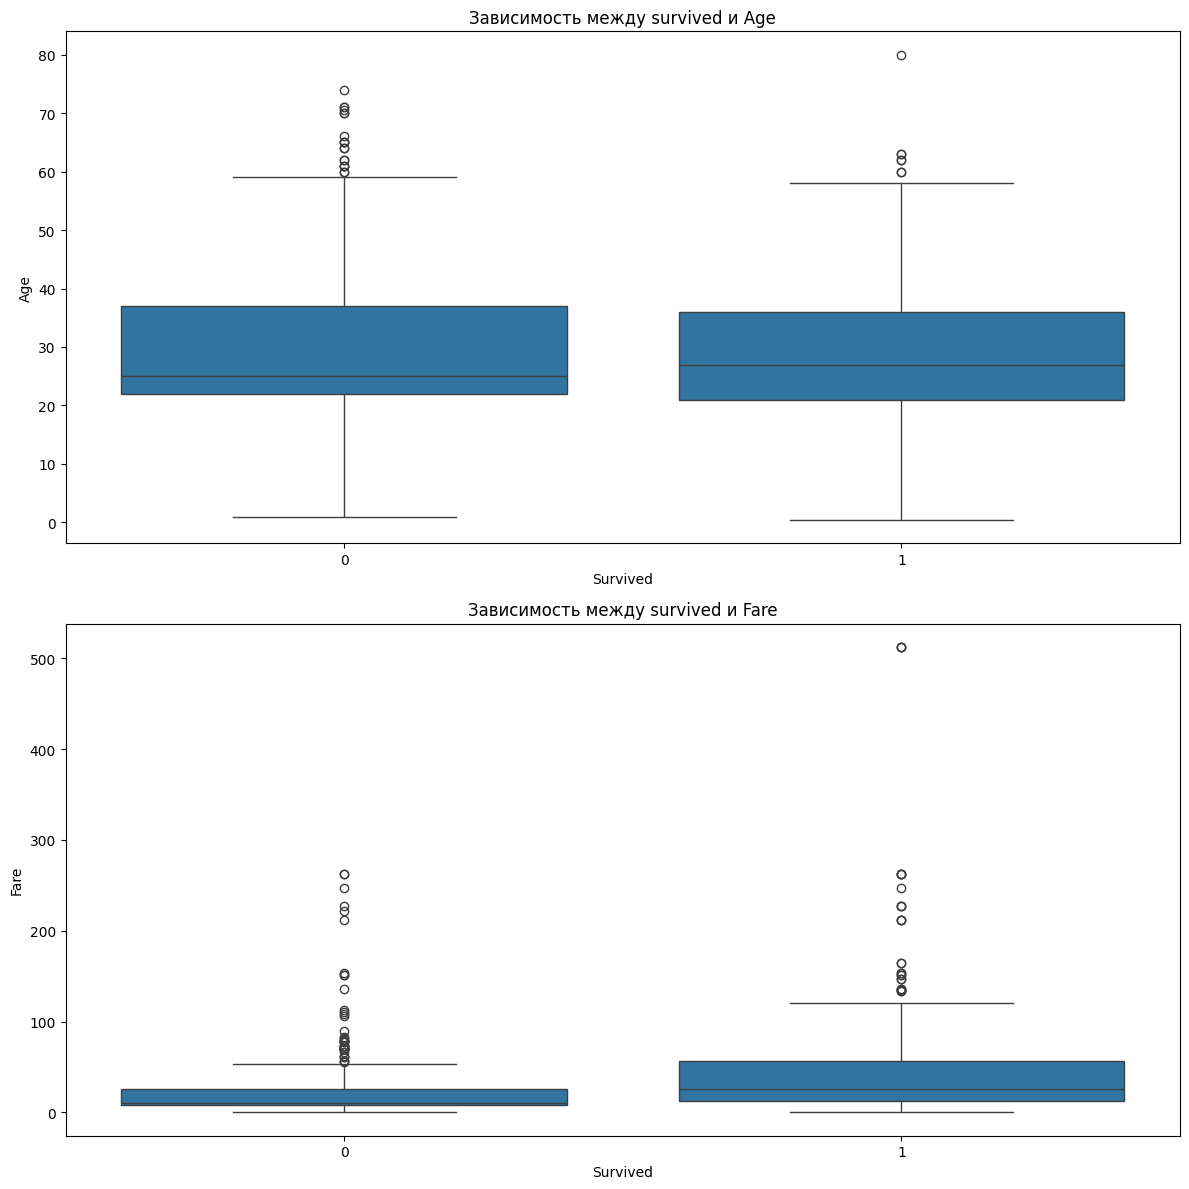

In [18]:
fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 6 * len(num_cols)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Survived', y=col, data=train, ax=axes[i])
    axes[i].set_title(f"Зависимость между survived и {col}")
plt.tight_layout()
plt.show()

Здесь можно сделать вывод, что разницы в возрасте почти не было, но была сильная разница в цене билета, от этог можно сделать еще один вывод, что цена билета имеет довольно большой вес в предсказании

Сделаю подобный анализ для категориальных признаков

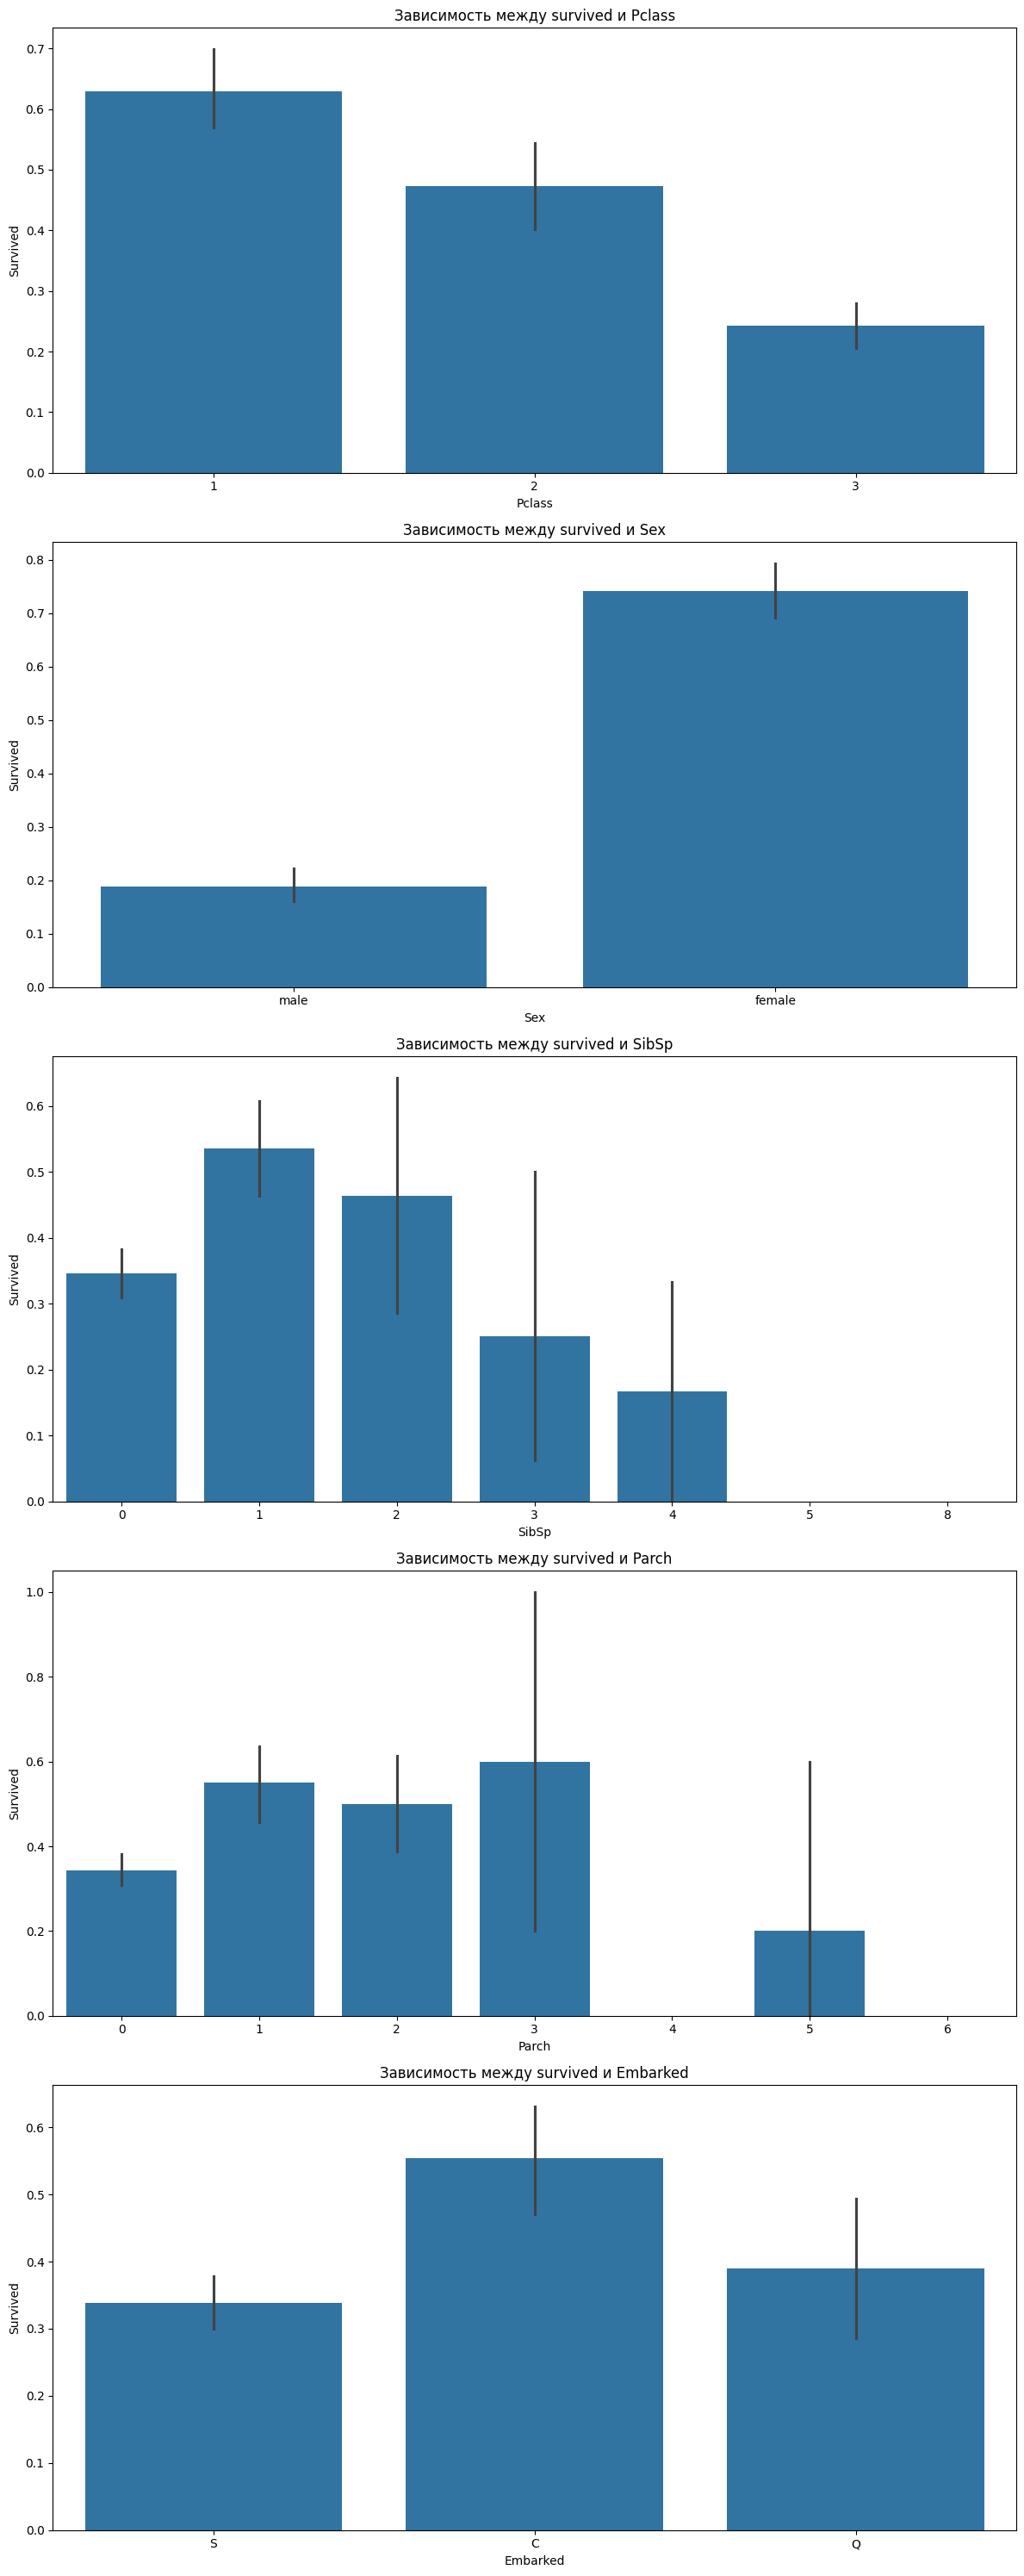

In [19]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 6 * len(cat_cols)))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(x=col, y="Survived", data=train, ax=axes[i])
    axes[i].set_title(f"Зависимость между survived и {col}")
plt.tight_layout()
plt.show()

По этим графикам можно увидеть, что женщины выживали чаще, как и пассажири первого класса

Теперь можно попробовать объединять разные признаки для поиска взаимодействия признаков

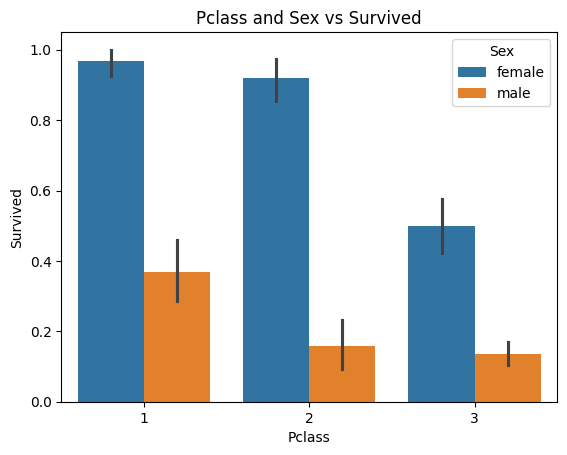

In [20]:
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=train)
plt.title('Pclass and Sex vs Survived')
plt.show()

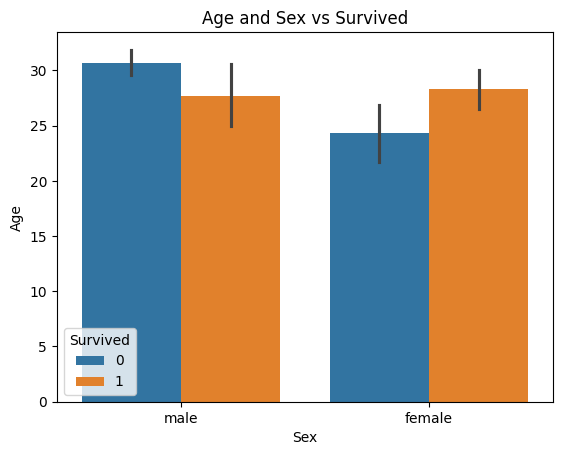

In [21]:
sns.barplot(x="Sex", y="Age", hue="Survived", data=train)
plt.title('Age and Sex vs Survived')
plt.show()

Исходя из увиденного на этих графиках я могу сделать вывод, что наиболее важными признаками являются пол, класс, которым шел пассажир и цена его билета(которая зависит от его класса)

In [22]:
ohe_list = ["Sex", "Embarked", "Pclass"]

ohe = OneHotEncoder(sparse_output=False, dtype=int)
for ohe_col in ohe_list:
    ohe_train = ohe.fit_transform(train[[ohe_col]])
    df_ohe_train = pd.DataFrame(ohe_train, columns=ohe.get_feature_names_out([ohe_col]), index=train.index)
    train = pd.concat([train.drop(columns=ohe_col), df_ohe_train], axis=1)

    ohe_test = ohe.transform(test[[ohe_col]])
    df_ohe_test = pd.DataFrame(ohe_test, columns=ohe.get_feature_names_out([ohe_col]), index=test.index)
    test = pd.concat([test.drop(columns=ohe_col), df_ohe_test], axis=1)

In [23]:
list_norm = ["Age", "SibSp", "Parch"]


for col in list_norm:
    normal = MinMaxScaler()
    train[col + "_norm"] = normal.fit_transform(train[[col]])
    train.drop(columns=col, inplace=True)

    test[col + "_norm"] = normal.transform(test[[col]])
    test.drop(columns=col, inplace=True)

In [24]:
stand = StandardScaler()
train["Fare_scaled"] = stand.fit_transform(train[["Fare"]])
train.drop(columns="Fare", inplace=True)

test["Fare_scaled"] = stand.transform(test[["Fare"]])
test.drop(columns="Fare", inplace=True)

In [25]:
X = train.drop(columns=["Survived", "PassengerId"])
y = train["Survived"]

X_test = test.drop(columns="PassengerId")

Обучу логрег на 10 фолдах

In [26]:
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = LogisticRegression()
    model.fit(train_X_fold, train_y_fold)

    pred = model.predict(val_X_fold)
    score = accuracy_score(val_y_fold, pred)
    scores.append(score)
print(f"mean accuracy score is {np.mean(scores)}")

mean accuracy score is 0.8047815230961298


теперь сделаю предсказания на тестовой выборке

In [27]:
model = LogisticRegression()
model.fit(X, y)
pred = model.predict(X_test)

In [88]:
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = LogisticRegression(penalty="l2", C=1e-2)
    model.fit(train_X_fold, train_y_fold)

    pred = model.predict(val_X_fold)
    score = accuracy_score(val_y_fold, pred)
    scores.append(score)
print(f"mean accuracy score is {np.mean(scores)}")

mean accuracy score is 0.7833832709113608


c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

In [91]:
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = LogisticRegression(solver="liblinear", penalty="l1", C=1e-2)
    model.fit(train_X_fold, train_y_fold)

    pred = model.predict(val_X_fold)
    score = accuracy_score(val_y_fold, pred)
    scores.append(score)
print(f"mean accuracy score is {np.mean(scores)}")

mean accuracy score is 0.616167290886392


c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1

In [94]:
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = LogisticRegression(solver="saga", penalty="elasticnet", C=1e-2, l1_ratio=0.5)
    model.fit(train_X_fold, train_y_fold)

    pred = model.predict(val_X_fold)
    score = accuracy_score(val_y_fold, pred)
    scores.append(score)
print(f"mean accuracy score is {np.mean(scores)}")

mean accuracy score is 0.709350811485643


c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nikolay\Desktop\ml_roadmap\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

Теперь посмотрю показатель Roc Auc на дереве решений

In [28]:
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=21
    )
    model.fit(train_X_fold, train_y_fold)

    probs = model.predict_proba(val_X_fold)[:, 1]
    score = roc_auc_score(val_y_fold, probs)
    scores.append(score)
print(f"mean roc_auc score is {np.mean(scores)}")

mean roc_auc score is 0.8537407407407407


In [29]:
model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=21
    )
model.fit(X, y)
pred = model.predict(X_test)

Random Forest Cl

In [30]:
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=21
    )
    model.fit(train_X_fold, train_y_fold)

    probs = model.predict_proba(val_X_fold)[:, 1]
    score = roc_auc_score(val_y_fold, probs)
    scores.append(score)
print(f"mean roc_auc score is {np.mean(scores)}")

mean roc_auc score is 0.8576356362612492


In [31]:
model = RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=21
)
model.fit(X, y)
pred = model.predict(X_test)

CatBoost

In [32]:
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = CatBoostClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        depth=3,
        l2_leaf_reg=3,
        eval_metric="AUC",
        early_stopping_rounds=50,
        verbose=False,
        random_state=21
    )
    model.fit(train_X_fold, train_y_fold, eval_set=(val_X_fold, val_y_fold))

    probs = model.predict_proba(val_X_fold)[:, 1]
    score = roc_auc_score(val_y_fold, probs)
    scores.append(score)
print(f"mean roc_auc score is {np.mean(scores)}")
print("std:", np.std(scores))

mean roc_auc score is 0.8743127798314452
std: 0.02303610571839229


In [33]:
model = CatBoostClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    depth=3,
    l2_leaf_reg=3,
    eval_metric="AUC",
    early_stopping_rounds=50,
    verbose=False,
    random_state=21
)
model.fit(X, y)
pred = model.predict(X_test)

lightgbm

In [34]:
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=8,
        max_depth=3,
        min_data_in_leaf=30,
        lambda_l2=3,
        lambda_l1=1,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=21
    )

model.fit(
    train_X_fold, train_y_fold,
    eval_set=[(val_X_fold, val_y_fold)]
)

probs = model.predict_proba(val_X_fold)[:, 1]
score = roc_auc_score(val_y_fold, probs)
scores.append(score)
print(f"mean roc_auc score is {np.mean(scores)}")
print("std:", np.std(scores))

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=3, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=3, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3
[LightGBM] [Info] Number of positive: 273, number of negative: 440
[LightGBM] [Info] Auto-choosing row-wise multi-thread

In [35]:
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    reg_lambda=3,
    reg_alpha=1,
    random_state=21
)

model.fit(X, y)
pred = model.predict(X_test)

[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 230
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

xgboost

In [36]:
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

scores = []
for train_idx, val_idx in sk.split(X, y):
    train_X_fold = X.iloc[train_idx]
    val_X_fold = X.iloc[val_idx]

    train_y_fold = y.iloc[train_idx]
    val_y_fold = y.iloc[val_idx]
    
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=3,
        reg_lambda = 1,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=21
    )
    model.fit(train_X_fold, train_y_fold, eval_set=[(val_X_fold, val_y_fold)], verbose=False)

    probs = model.predict_proba(val_X_fold)[:, 1]
    score = roc_auc_score(val_y_fold, probs)
    scores.append(score)
print(f"mean roc_auc score is {np.mean(scores)}")
print("std:", np.std(scores))

mean roc_auc score is 0.8747590969883257
std: 0.021735987760603648


In [37]:
model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=3,
        reg_lambda = 1,
        eval_metric="auc",
        random_state=21
)
model.fit(X, y)
pred = model.predict(X_test)

Попробую применить pytorch для построения модели


In [38]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=21)

In [54]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 5),
    nn.ReLU(),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, weight_decay=1e-4)

In [100]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

In [96]:
def train_model(model, X_train, y_train, X_val, y_val, optimizer, loss_fn, sheduler=None, n_epoch=100, batch_size=16):
    for epoch in range(n_epoch):
        model.train()
        loss_history = []
        tp = 0  
        all_p = 0  
        indices = torch.randperm(X_train.shape[0])
        for start in range(0, X_train.shape[0], batch_size):
            batch_idx = indices[start:start+batch_size]
            x_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]
            
            optimizer.zero_grad()
            logits = model(x_batch)
            loss_val = loss_fn(logits, y_batch)
            loss_val.backward()
            optimizer.step()
            
            loss_history.append(loss_val.item())
            
            probs = torch.sigmoid(logits)
            pred = (probs > 0.5).float()
            tp += (pred == y_batch).sum().item()
            all_p += y_batch.shape[0]
            
        if sheduler is not None:
            sheduler.step()
        
        ave_loss = np.mean(loss_history)
        train_acc = tp / all_p
        val_acc = compute_accuracy(model, X_val, y_val)

        print(f"Epoch {epoch}: Loss = {ave_loss:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")


def compute_accuracy(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        logits = model(X_val)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()
        true_pred = (pred == y_val).sum().item()
        all_pred = y_val.shape[0]
        
    return true_pred / all_pred

In [57]:
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss, n_epoch=30)

Epoch 0: Loss = 0.4594 | Train Acc = 0.7851 | Val Acc = 0.7821
Epoch 1: Loss = 0.4587 | Train Acc = 0.7851 | Val Acc = 0.7821
Epoch 2: Loss = 0.4561 | Train Acc = 0.7879 | Val Acc = 0.7821
Epoch 3: Loss = 0.4586 | Train Acc = 0.7879 | Val Acc = 0.7821
Epoch 4: Loss = 0.4569 | Train Acc = 0.7893 | Val Acc = 0.7821
Epoch 5: Loss = 0.4585 | Train Acc = 0.7907 | Val Acc = 0.7821
Epoch 6: Loss = 0.4545 | Train Acc = 0.7921 | Val Acc = 0.7821
Epoch 7: Loss = 0.4555 | Train Acc = 0.7893 | Val Acc = 0.7877
Epoch 8: Loss = 0.4575 | Train Acc = 0.7907 | Val Acc = 0.7877
Epoch 9: Loss = 0.4524 | Train Acc = 0.7921 | Val Acc = 0.7877
Epoch 10: Loss = 0.4535 | Train Acc = 0.7921 | Val Acc = 0.7877
Epoch 11: Loss = 0.4555 | Train Acc = 0.7907 | Val Acc = 0.7877
Epoch 12: Loss = 0.4560 | Train Acc = 0.7893 | Val Acc = 0.7877
Epoch 13: Loss = 0.4533 | Train Acc = 0.7893 | Val Acc = 0.7877
Epoch 14: Loss = 0.4529 | Train Acc = 0.7935 | Val Acc = 0.7877
Epoch 15: Loss = 0.4541 | Train Acc = 0.7935 | Val

добавил слой

In [99]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, weight_decay=1e-4)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss)

Epoch 0: Loss = 0.7116 | Train Acc = 0.3764 | Val Acc = 0.4134
Epoch 1: Loss = 0.6996 | Train Acc = 0.3736 | Val Acc = 0.4860
Epoch 2: Loss = 0.6891 | Train Acc = 0.5871 | Val Acc = 0.5307
Epoch 3: Loss = 0.6803 | Train Acc = 0.6124 | Val Acc = 0.5922
Epoch 4: Loss = 0.6726 | Train Acc = 0.6264 | Val Acc = 0.5866
Epoch 5: Loss = 0.6663 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 6: Loss = 0.6598 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 7: Loss = 0.6549 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 8: Loss = 0.6491 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 9: Loss = 0.6444 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 10: Loss = 0.6403 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 11: Loss = 0.6340 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 12: Loss = 0.6309 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 13: Loss = 0.6252 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 14: Loss = 0.6202 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 15: Loss = 0.6140 | Train Acc = 0.6236 | Val

dropout

In [59]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, weight_decay=1e-4)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss)

Epoch 0: Loss = 0.6698 | Train Acc = 0.6152 | Val Acc = 0.5866
Epoch 1: Loss = 0.6695 | Train Acc = 0.6208 | Val Acc = 0.5866
Epoch 2: Loss = 0.6691 | Train Acc = 0.6124 | Val Acc = 0.5866
Epoch 3: Loss = 0.6674 | Train Acc = 0.6166 | Val Acc = 0.5866
Epoch 4: Loss = 0.6641 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 5: Loss = 0.6594 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 6: Loss = 0.6583 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 7: Loss = 0.6594 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 8: Loss = 0.6509 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 9: Loss = 0.6591 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 10: Loss = 0.6563 | Train Acc = 0.6264 | Val Acc = 0.5866
Epoch 11: Loss = 0.6567 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 12: Loss = 0.6534 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 13: Loss = 0.6536 | Train Acc = 0.6264 | Val Acc = 0.5866
Epoch 14: Loss = 0.6556 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 15: Loss = 0.6494 | Train Acc = 0.6278 | Val

разные optim и разные значения в optim

In [72]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-2)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss, n_epoch=100)

Epoch 0: Loss = 0.6547 | Train Acc = 0.6713 | Val Acc = 0.7821
Epoch 1: Loss = 0.5706 | Train Acc = 0.7233 | Val Acc = 0.7933
Epoch 2: Loss = 0.5031 | Train Acc = 0.7809 | Val Acc = 0.7989
Epoch 3: Loss = 0.5082 | Train Acc = 0.7739 | Val Acc = 0.8045
Epoch 4: Loss = 0.5124 | Train Acc = 0.7851 | Val Acc = 0.7989
Epoch 5: Loss = 0.5097 | Train Acc = 0.7697 | Val Acc = 0.7933
Epoch 6: Loss = 0.5105 | Train Acc = 0.7879 | Val Acc = 0.7989
Epoch 7: Loss = 0.4847 | Train Acc = 0.7907 | Val Acc = 0.7989
Epoch 8: Loss = 0.5056 | Train Acc = 0.7879 | Val Acc = 0.8212
Epoch 9: Loss = 0.5049 | Train Acc = 0.7893 | Val Acc = 0.7989
Epoch 10: Loss = 0.5162 | Train Acc = 0.7753 | Val Acc = 0.7877
Epoch 11: Loss = 0.5005 | Train Acc = 0.7753 | Val Acc = 0.7989
Epoch 12: Loss = 0.5039 | Train Acc = 0.7809 | Val Acc = 0.7989
Epoch 13: Loss = 0.4941 | Train Acc = 0.7795 | Val Acc = 0.7989
Epoch 14: Loss = 0.5011 | Train Acc = 0.7893 | Val Acc = 0.7933
Epoch 15: Loss = 0.4848 | Train Acc = 0.8062 | Val

In [73]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-2)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss, n_epoch=100)

Epoch 0: Loss = 0.6701 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 1: Loss = 0.6618 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 2: Loss = 0.6648 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 3: Loss = 0.6575 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 4: Loss = 0.6520 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 5: Loss = 0.6472 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 6: Loss = 0.6391 | Train Acc = 0.6236 | Val Acc = 0.5866
Epoch 7: Loss = 0.6132 | Train Acc = 0.6250 | Val Acc = 0.5866
Epoch 8: Loss = 0.6064 | Train Acc = 0.6629 | Val Acc = 0.6201
Epoch 9: Loss = 0.6089 | Train Acc = 0.6685 | Val Acc = 0.7709
Epoch 10: Loss = 0.5871 | Train Acc = 0.7303 | Val Acc = 0.7709
Epoch 11: Loss = 0.5829 | Train Acc = 0.7065 | Val Acc = 0.7598
Epoch 12: Loss = 0.5589 | Train Acc = 0.7177 | Val Acc = 0.7765
Epoch 13: Loss = 0.5693 | Train Acc = 0.7177 | Val Acc = 0.7709
Epoch 14: Loss = 0.5525 | Train Acc = 0.7177 | Val Acc = 0.7877
Epoch 15: Loss = 0.5479 | Train Acc = 0.7191 | Val

In [ ]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-2, weight_decay=1e-2, momentum=0.9)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss, n_epoch=100)

Epoch 0: Loss = 0.7208 | Train Acc = 0.5927 | Val Acc = 0.6257
Epoch 1: Loss = 0.6063 | Train Acc = 0.6868 | Val Acc = 0.7933
Epoch 2: Loss = 0.6196 | Train Acc = 0.7107 | Val Acc = 0.5978
Epoch 3: Loss = 0.6382 | Train Acc = 0.6573 | Val Acc = 0.5866
Epoch 4: Loss = 0.6237 | Train Acc = 0.6826 | Val Acc = 0.7821
Epoch 5: Loss = 0.6164 | Train Acc = 0.6966 | Val Acc = 0.7318
Epoch 6: Loss = 0.5847 | Train Acc = 0.7149 | Val Acc = 0.6536
Epoch 7: Loss = 0.5929 | Train Acc = 0.6980 | Val Acc = 0.7709
Epoch 8: Loss = 0.5936 | Train Acc = 0.7219 | Val Acc = 0.7821
Epoch 9: Loss = 0.6150 | Train Acc = 0.6980 | Val Acc = 0.6425
Epoch 10: Loss = 0.5845 | Train Acc = 0.7022 | Val Acc = 0.7877
Epoch 11: Loss = 0.6169 | Train Acc = 0.6980 | Val Acc = 0.7877
Epoch 12: Loss = 0.6120 | Train Acc = 0.7008 | Val Acc = 0.7877
Epoch 13: Loss = 0.6472 | Train Acc = 0.6685 | Val Acc = 0.6425
Epoch 14: Loss = 0.6146 | Train Acc = 0.6840 | Val Acc = 0.6313
Epoch 15: Loss = 0.6189 | Train Acc = 0.6924 | Val

In [97]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-2)
sheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.2)
train_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, optimizer, loss, sheduler, n_epoch=100)

Epoch 0: Loss = 0.6245 | Train Acc = 0.6461 | Val Acc = 0.7598
Epoch 1: Loss = 0.5600 | Train Acc = 0.7444 | Val Acc = 0.7821
Epoch 2: Loss = 0.5407 | Train Acc = 0.7669 | Val Acc = 0.7989
Epoch 3: Loss = 0.5170 | Train Acc = 0.7640 | Val Acc = 0.7933
Epoch 4: Loss = 0.5006 | Train Acc = 0.7823 | Val Acc = 0.7989
Epoch 5: Loss = 0.5194 | Train Acc = 0.7626 | Val Acc = 0.7989
Epoch 6: Loss = 0.5053 | Train Acc = 0.7640 | Val Acc = 0.7933
Epoch 7: Loss = 0.4935 | Train Acc = 0.7584 | Val Acc = 0.7989
Epoch 8: Loss = 0.5243 | Train Acc = 0.7697 | Val Acc = 0.7933
Epoch 9: Loss = 0.5012 | Train Acc = 0.7781 | Val Acc = 0.7989
Epoch 10: Loss = 0.5101 | Train Acc = 0.7767 | Val Acc = 0.7989
Epoch 11: Loss = 0.4959 | Train Acc = 0.7795 | Val Acc = 0.7989
Epoch 12: Loss = 0.5164 | Train Acc = 0.7711 | Val Acc = 0.7989
Epoch 13: Loss = 0.5064 | Train Acc = 0.7781 | Val Acc = 0.7989
Epoch 14: Loss = 0.5155 | Train Acc = 0.7753 | Val Acc = 0.8045
Epoch 15: Loss = 0.5231 | Train Acc = 0.7753 | Val

анасамбль Avarage

In [ ]:
model1 = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

model2 = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(5,1)
)

model3 = nn.Sequential(
    nn.Linear(X.shape[1], 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5,1)
)

loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-2)
models = [model1, model2, model3]


res = []
for model in models:
    model.eval()
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)
    res.append(probs)
res_probs = torch.mean(torch.stack(res), dim=0)
res_pred = (res_probs > 0.5).float()